In [9]:
import pandas as pd

In [10]:
csv = pd.read_csv("platzierungen.csv")

platzierung = csv[csv["Jahr"] != 1956]

anzahl_teilnehmer_csv = pd.read_csv("anzahl_teilnehmer.csv")

df = platzierung.merge(
    anzahl_teilnehmer_csv,
    on = "Jahr",
    how = "inner"
)

df["Platzierung_prozent"] = (1 - (df["Platzierung"] - 1) / (df["Teilnehmer"] - 1)) * 100

print(df[["Genre", "Jahr", "Platzierung_prozent"]])

          Genre  Jahr  Platzierung_prozent
0           Pop  1957            22.222222
1      Schlager  1957            66.666667
2        Ballad  1957            33.333333
3      Schlager  1957            44.444444
4      Schlager  1957             0.000000
...         ...   ...                  ...
1456  Dance-Pop  2026            25.000000
1457        Pop  2026            83.333333
1458  Dance-Pop  2026            45.833333
1459        Pop  2026            91.666667
1460  Dance-Pop  2026             4.166667

[1461 rows x 3 columns]


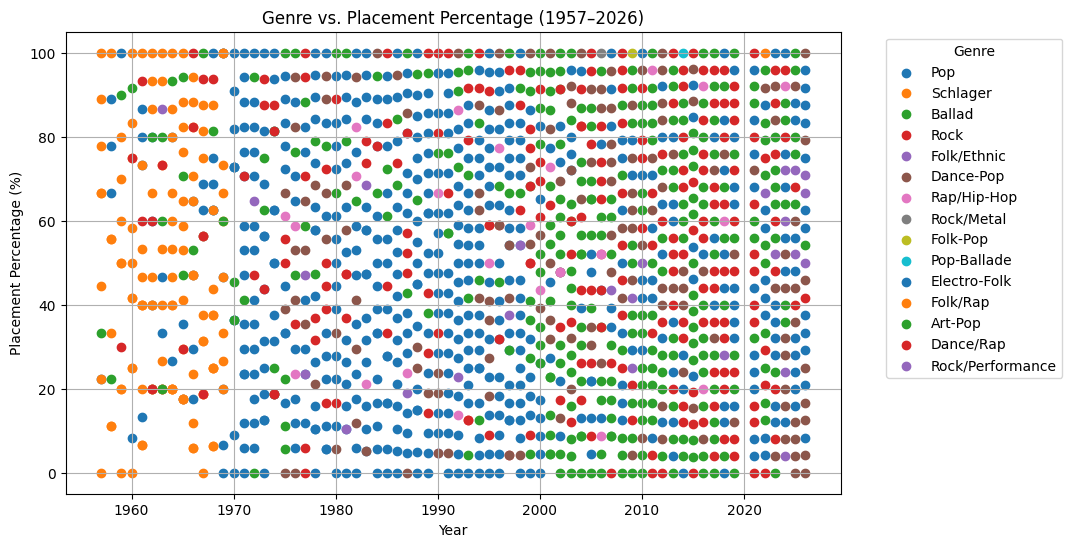

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for genre in df["Genre"].unique():
    genre_df = df[df["Genre"] == genre]
    plt.scatter(
        genre_df["Jahr"],
        genre_df["Platzierung_prozent"],
        label=genre
    )

plt.title("Genre vs. Placement Percentage (1957–2026)")
plt.xlabel("Year")
plt.ylabel("Placement Percentage (%)")
plt.grid()
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [12]:
genre_stats = (
    df.groupby("Genre")
      .agg(
          Teilnahmen=("Genre", "size"),
          Durchschnitt=("Platzierung_prozent", "mean")
      )
)

genre_stats_filterest = genre_stats[genre_stats["Teilnahmen"] >= 5]

print(
    genre_stats_filterest.sort_values(
        "Durchschnitt",
        ascending=False
    )
)

             Teilnahmen  Durchschnitt
Genre                                
Rap/Hip-Hop          23     55.610096
Rock                232     54.835912
Ballad              312     52.157023
Dance-Pop           154     51.101797
Schlager            124     49.290204
Pop                 582     47.909777
Folk/Ethnic          26     44.823970
